# Global Energy Transition Analysis
### Exploratory Data Analysis on Energy Consumption Patterns across Major Economies (2015 to 2022)

This notebook analyses real-world energy data sourced from Our World in Data across ten major economies. 
The goal is to understand how energy consumption patterns have shifted over time, which countries are 
leading the renewable transition, and what the data reveals about the gap between climate commitments 
and actual energy behaviour.

**Dataset:** Our World in Data - Energy Dataset  
**Scope:** 10 countries, 2015 to 2022, 8 energy sources  
**Tools:** Python, Pandas, Matplotlib, Seaborn, MySQL, SQLAlchemy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from urllib.parse import quote_plus
import os
import warnings

warnings.filterwarnings('ignore')


load_dotenv(dotenv_path=os.path.join(os.getcwd(), '../.env'))

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

connection_string = f"mysql+pymysql://{DB_USER}:{quote_plus(DB_PASSWORD)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

sns.set_style('whitegrid', {'axes.grid' : False})
plt.rcParams['figure.figsize'] = (12, 5)

print("Setup complete. Connected to:", DB_NAME)

Setup complete. Connected to: energy_analyzer


In [3]:
# Loading Data from SQL... 

with engine.connect() as conn:
    df_consumption = pd.read_sql("""
         SELECT 
            dc.country_name,
            dc.continent,
            des.source_name,
            des.source_type,
            des.is_renewable,
            dy.year,
            dy.is_post_paris,
            fc.consumption_twh
        FROM fact_consumption AS fc
        JOIN dim_country AS dc ON fc.country_id = dc.country_id
        JOIN dim_energy_source AS des ON fc.source_id = des.source_id
        JOIN dim_year AS dy ON fc.year = dy.year
    """, conn)

    df_meta = pd.read_sql("""
        SELECT 
            dc.country_name,
            fcm.year,
            fcm.population,
            fcm.gdp_usd,
            fcm.gdp_per_capita
        FROM fact_country_meta AS fcm
        JOIN dim_country AS dc ON fcm.country_id = dc.country_id
    """, conn)

print("Consumption table shape: ", df_consumption.shape)
print("Meta table shape: ", df_meta.shape)
print("\n Sample: \n")
print(df_consumption.head(10))
    

Consumption table shape:  (640, 8)
Meta table shape:  (80, 5)

 Sample: 

  country_name continent source_name source_type  is_renewable  year  \
0        India      Asia     Biofuel   Renewable             1  2015   
1        India      Asia     Biofuel   Renewable             1  2016   
2        India      Asia     Biofuel   Renewable             1  2017   
3        India      Asia     Biofuel   Renewable             1  2018   
4        India      Asia     Biofuel   Renewable             1  2019   
5        India      Asia     Biofuel   Renewable             1  2020   
6        India      Asia     Biofuel   Renewable             1  2021   
7        India      Asia     Biofuel   Renewable             1  2022   
8        India      Asia     Nuclear     Nuclear             0  2015   
9        India      Asia     Nuclear     Nuclear             0  2016   

   is_post_paris  consumption_twh  
0              0            3.592  
1              1            7.590  
2              1         

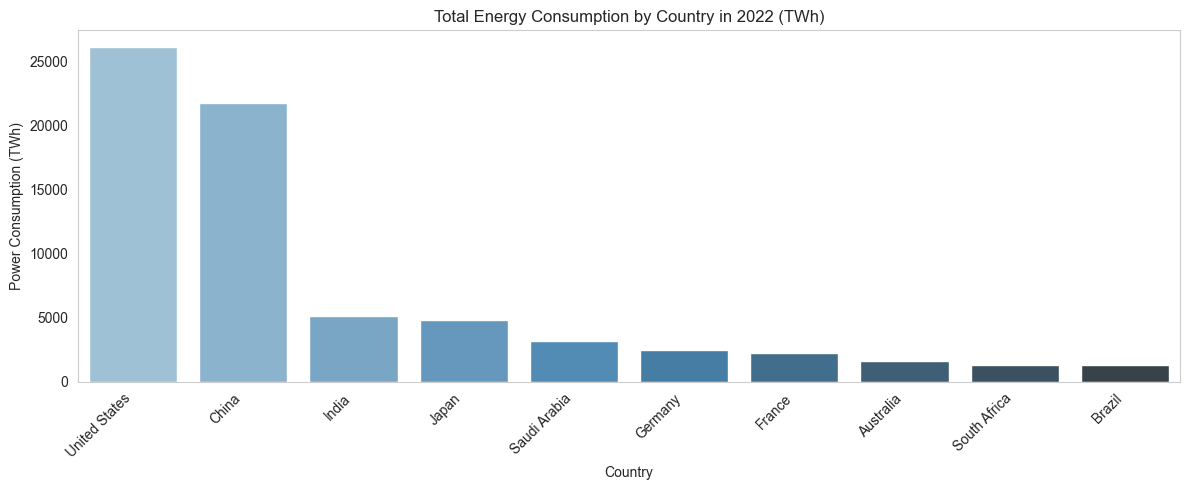



    country_name  consumption_twh
0  United States        26124.858
1          China        21741.026
2          India         5158.742
3          Japan         4849.459
4   Saudi Arabia         3149.753
5        Germany         2461.034
6         France         2246.738
7      Australia         1637.969
8   South Africa         1341.709
9         Brazil         1341.005


In [17]:
# Totol Energy consumption by each country in year 2022

df_2022 = df_consumption[df_consumption['year'] == 2022]

country_total = df_2022.groupby('country_name')['consumption_twh'].sum().sort_values(ascending=False).reset_index()

print("\n")
plt.figure(figsize=(12, 5))
sns.barplot(data=country_total, x='country_name', y='consumption_twh', palette='Blues_d')
plt.title('Total Energy Consumption by Country in 2022 (TWh)')
plt.xlabel('Country')
plt.ylabel('Power Consumption (TWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n")

print(country_total)


### Key Insight:  Total Energy Consumption by Country in 2022

China and the United States stand out as the two largest energy consumers in 2022 by a significant margin. The gap between these two and the remaining eight countries is substantial, which reflects both their large populations and their heavily industrialized economies. Countries like France, South Africa and Saudi Arabia show comparatively modest total consumption figures.

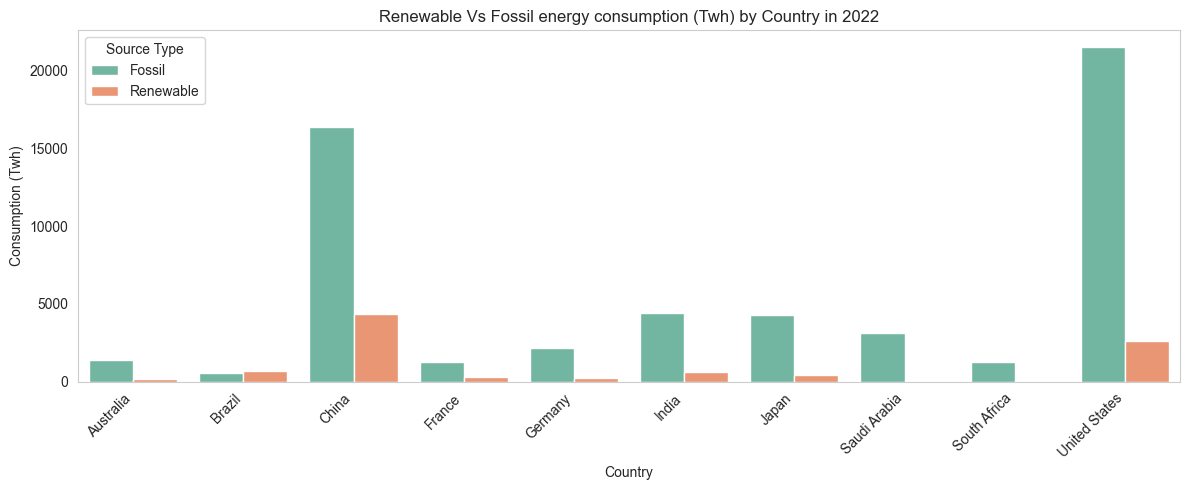



     country_name source_type  consumption_twh
0       Australia      Fossil         1429.625
1       Australia   Renewable          208.344
2          Brazil      Fossil          587.643
3          Brazil   Renewable          717.590
4           China      Fossil        16374.868
5           China   Renewable         4339.672
6          France      Fossil         1240.296
7          France   Renewable          282.287
8         Germany      Fossil         2159.790
9         Germany   Renewable          269.244
10          India      Fossil         4407.038
11          India   Renewable          638.204
12          Japan      Fossil         4286.361
13          Japan   Renewable          435.889
14   Saudi Arabia      Fossil         3144.814
15   Saudi Arabia   Renewable            4.939
16   South Africa      Fossil         1269.034
17   South Africa   Renewable           47.859
18  United States      Fossil        21487.639
19  United States   Renewable         2641.778


In [5]:
# Renewable energy Vs Fossil energy consumption Breakdown by country for year 2022

renewable_vs_fossil = df_2022[df_2022['source_type'] != 'Nuclear'].groupby(['country_name', 'source_type'])['consumption_twh'].sum().reset_index()

print("\n")
plt.figure(figsize=(12, 5))
sns.barplot(data=renewable_vs_fossil, x='country_name', y='consumption_twh', palette='Set2', hue='source_type')
plt.title('Renewable Vs Fossil energy consumption (Twh) by Country in 2022')
plt.xlabel('Country')
plt.ylabel('Consumption (Twh)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Source Type')
plt.tight_layout()
plt.show()

print("\n")
print(renewable_vs_fossil)

### Key Insight: Renewable vs Fossil Breakdown

When we split consumption into renewable and fossil categories, China and the US again dominate the fossil side. However, what is interesting is that China shows a noticeably higher renewable bar compared to the US, which suggests that despite being a massive fossil consumer, China has been actively building renewable capacity in parallel. Most other countries in the dataset remain heavily fossil dependent with relatively small renewable contributions.

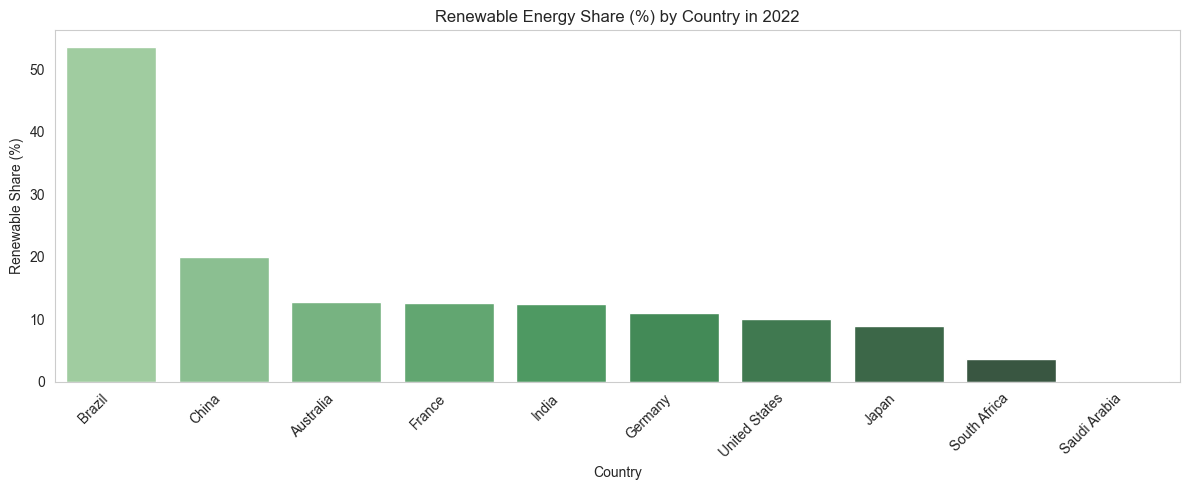



 country_name  renewable_share_pct
       Brazil            53.511359
        China            19.960751
    Australia            12.719655
       France            12.564304
        India            12.371311
      Germany            10.940280
United States            10.112124
        Japan             8.988405
 South Africa             3.567018
 Saudi Arabia             0.156806


In [12]:
# Renewable Share (%) by Country in 2022
total_by_country = df_2022.groupby('country_name')['consumption_twh'].sum().reset_index()
total_by_country.columns = ['country_name', 'total_twh']

renewable_by_country = df_2022[df_2022['is_renewable'] == 1].groupby('country_name')['consumption_twh'].sum().reset_index()
renewable_by_country.columns = ['country_name', 'renewable_twh']

share_df = pd.merge(total_by_country, renewable_by_country, on='country_name')
share_df['renewable_share_pct'] = (share_df['renewable_twh'] / share_df['total_twh']) * 100
share_df = share_df.sort_values('renewable_share_pct', ascending=False)

print("\n")
plt.figure(figsize=(12, 5))
sns.barplot(data=share_df, x='country_name', y='renewable_share_pct', palette='Greens_d')
plt.title('Renewable Energy Share (%) by Country in 2022')
plt.xlabel('Country')
plt.ylabel('Renewable Share (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n")
print(share_df[['country_name', 'renewable_share_pct']].to_string(index=False))

### Key Insights: Renewable Share Percentage

Brazil tops the renewable share chart with the highest percentage among all ten countries, driven almost entirely by hydroelectric power which benefits from its natural geography. China and Australia follow, though for different reasons. The most striking observation here is Saudi Arabia sitting at zero percent renewable share, making it completely dependent on fossil energy with no meaningful transition underway as of 2022. This makes Saudi Arabia the most vulnerable economy in any future carbon reduction scenario.

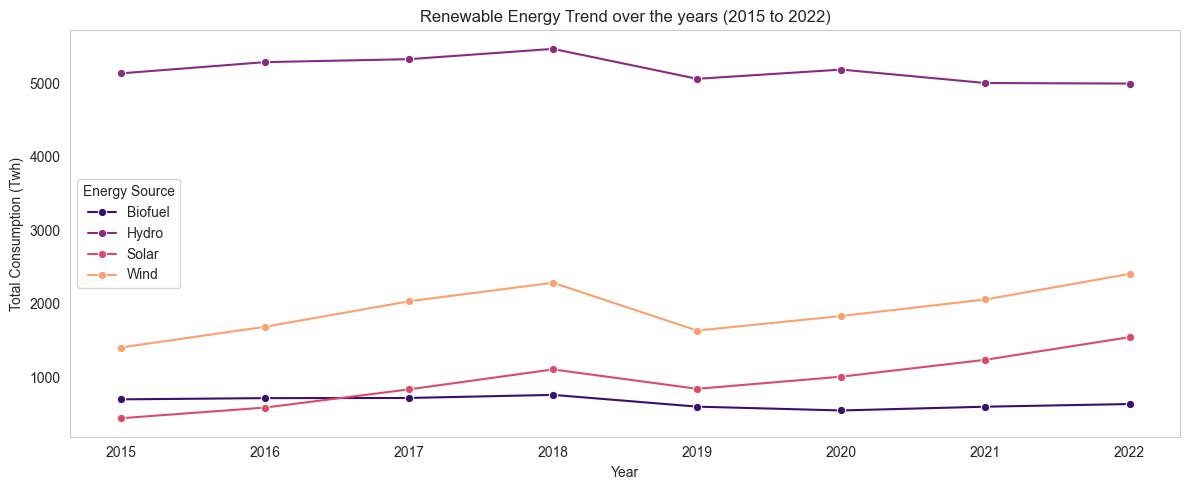

In [6]:
# Renewable Energy Trend Over Years (2015 to 2022)

renewable_trend = df_consumption[df_consumption['is_renewable'] == 1].groupby(['year', 'source_name'])['consumption_twh'].sum().reset_index()

# print(renewable_trend.to_string(index=False))
print("\n")
plt.figure(figsize=(12, 5))
sns.lineplot(data=renewable_trend, x='year', y='consumption_twh', hue='source_name', palette='magma', marker='o')
plt.title('Renewable Energy Trend over the years (2015 to 2022)')
plt.xlabel('Year')
plt.ylabel('Total Consumption (Twh)')
plt.legend(title='Energy Source')
plt.tight_layout()
plt.show()


### Key Insight: Global Renewable Trend

Looking at how renewable sources have grown from 2015 to 2022, solar energy shows the steepest and most consistent upward trajectory, especially from 2019 onwards. Biofuel consumption has seen a slight decline over the same period, possibly due to policy shifts favoring solar and wind investments. Wind energy shows a dip around 2018 to 2019 before recovering and growing steadily. Hydro remains largely flat throughout, which is expected given the geographical and capital constraints involved in building new hydroelectric infrastructure.

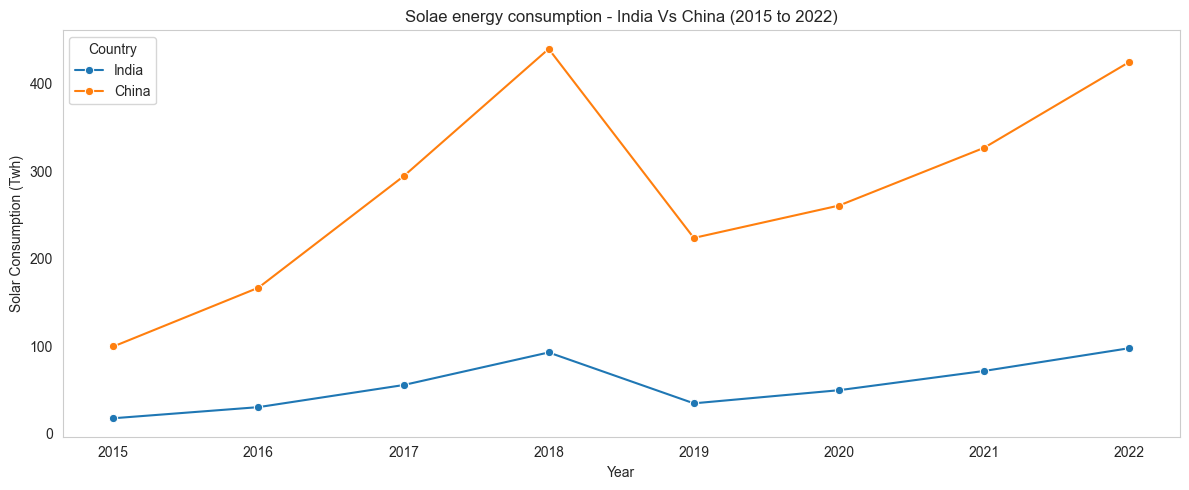

In [9]:
# India Vs China Solar Growth (2015 to 2022)

solar_india_china = df_consumption[(df_consumption['source_name'] == 'Solar') & (df_consumption['country_name'].isin(['India', 'China']))]

print("\n")
plt.figure(figsize=(12,5))
sns.lineplot(data=solar_india_china, x='year', y='consumption_twh', hue='country_name', marker='o')
plt.title('Solae energy consumption - India Vs China (2015 to 2022)')
plt.xlabel('Year')
plt.ylabel('Solar Consumption (Twh)')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

print("\n")

### Key Insight: India vs China Solar

Between 2015 and 2018, China grew its solar consumption at a dramatically faster rate than India. Both countries then experienced a notable dip in 2019, which coincides with China cutting its solar subsidies in 2018, an event that disrupted the global solar market and affected India as well since it imports a significant portion of its solar panels from China. From 2019 onwards, both countries resumed growth. China leads in absolute numbers but India's growth rate relative to its starting point is actually steeper, making India one of the fastest growing solar markets in percentage terms.

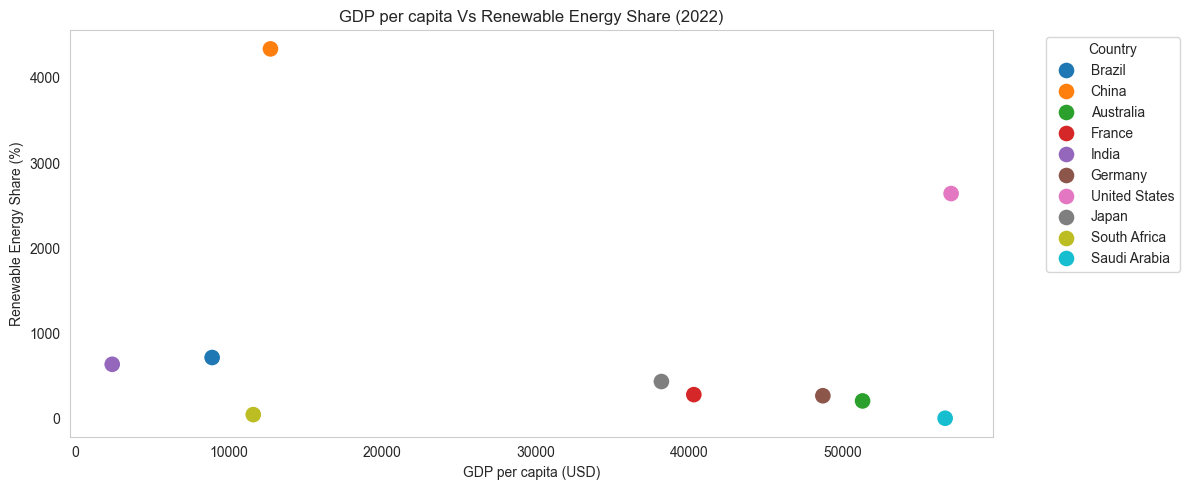

In [13]:
# GDP per capita Vs Renewable share pct

gdp_2022 = df_meta[df_meta['year'] == 2022][['country_name', 'gdp_per_capita']]

share_gdp = pd.merge(share_df, gdp_2022, on='country_name')

plt.figure(figsize=(12, 5))
sns.scatterplot(data=share_gdp, x='gdp_per_capita', y='renewable_twh', s=150,hue='country_name')
plt.title('GDP per capita Vs Renewable Energy Share (2022)')
plt.xlabel('GDP per capita (USD)')
plt.ylabel('Renewable Energy Share (%)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n")

### Key Insight: GDP per Capita vs Renewable Share

This scatter plot challenges a common assumption that wealthier countries naturally invest more in renewable energy. The data tells a different story. Saudi Arabia and Australia, both high income economies, show low renewable shares. Brazil and China, with lower GDP per capita figures, show much higher renewable contributions. This suggests that natural resource availability, geography and domestic policy drive renewable adoption more than national wealth does.


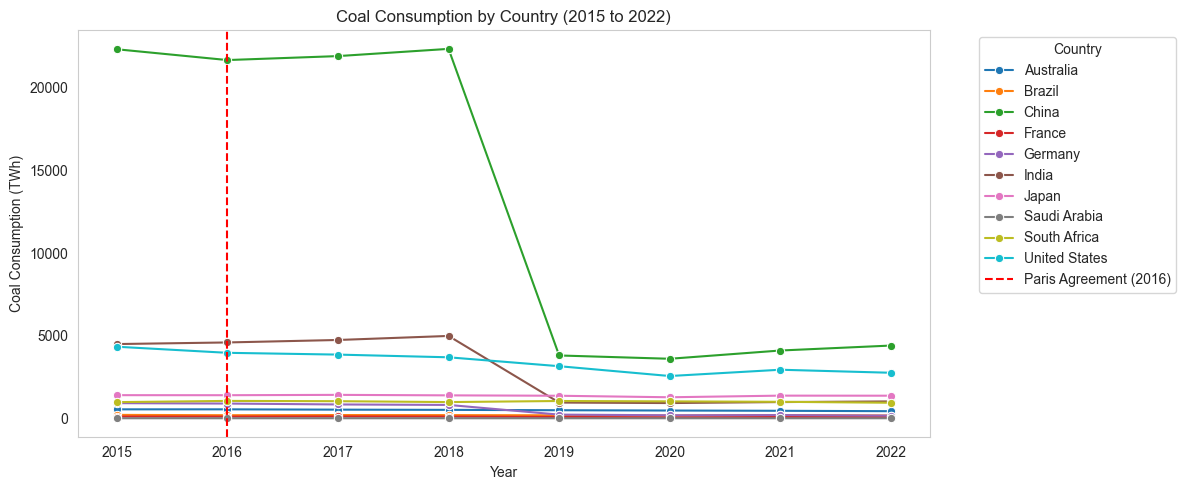

In [15]:
# Coal Consumption Trend Post Paris Agreement
coal_trend = df_consumption[df_consumption['source_name'] == 'Coal'].groupby(
    ['year', 'country_name'])['consumption_twh'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=coal_trend, x='year', y='consumption_twh', hue='country_name', marker='o')
plt.axvline(x=2016, color='red', linestyle='--', linewidth=1.5, label='Paris Agreement (2016)')
plt.title('Coal Consumption by Country (2015 to 2022)')
plt.xlabel('Year')
plt.ylabel('Coal Consumption (TWh)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n")

### Key Insight: Coal Consumption Post Paris

The vertical line at 2016 marks the Paris Agreement. Contrary to expectations, coal consumption for the heaviest users did not drop immediately after 2016. China, the largest coal consumer by far, only began showing a meaningful decline around 2018 to 2019. The US followed a similar pattern. For most other countries in the dataset, coal was never a dominant source to begin with. This suggests that international climate commitments alone did not drive coal reduction. The real factors were domestic air quality concerns in China, the economic competitiveness of natural gas in the US, and the falling cost of renewables making coal less attractive financially.

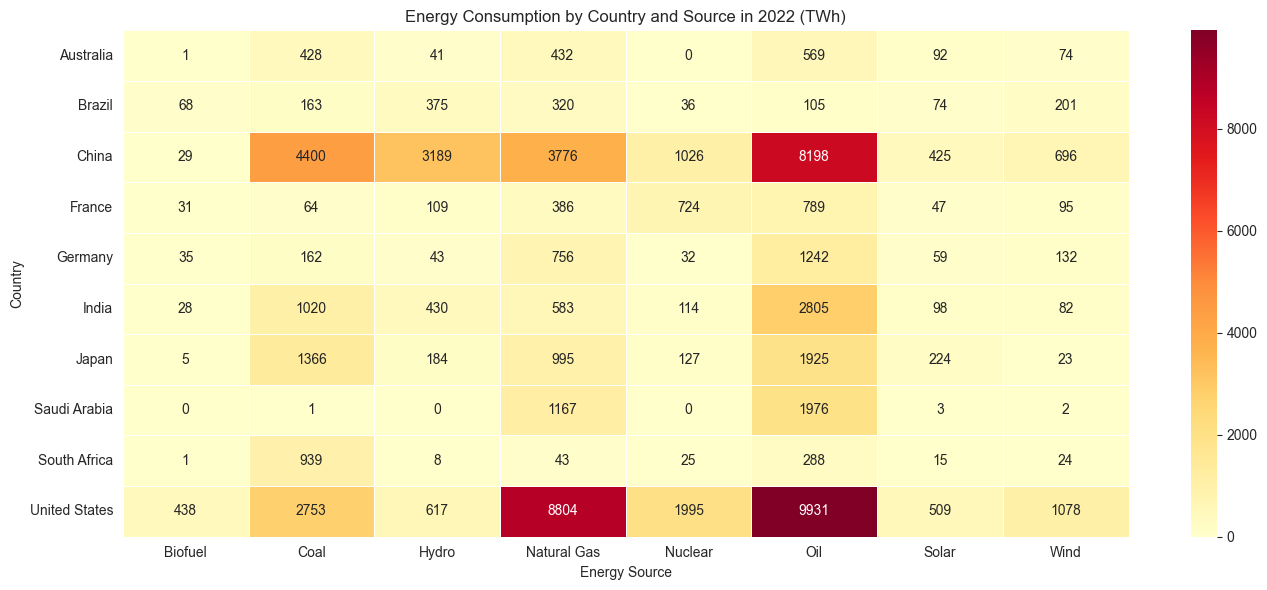

In [16]:
# Heatmap: Energy Consumption by Country and Source in 2022

heatmap_data = df_2022.groupby(['country_name', 'source_name'])['consumption_twh'].sum().unstack(fill_value=0)

print("\n")
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Energy Consumption by Country and Source in 2022 (TWh)')
plt.xlabel('Energy Source')
plt.ylabel('Country')
plt.tight_layout()
plt.show()
print("\n")

### Key Insight: Energy Consumption by Country

The heatmap gives a clear side by side view of how each country distributes its energy consumption across sources. China and the US dominate nearly every fossil fuel category, with China's coal cell being the darkest on the entire chart, reinforcing its position as the world's largest coal consumer. Oil consumption is high across both countries and notably elevated in Saudi Arabia relative to its population size. The lighter cells across renewable sources for most countries highlight how much room remains for renewable growth across the dataset.

## Conclusion

This analysis looked at energy consumption patterns across ten major economies from 2015 to 2022 using real world data from Our World in Data.

A few themes emerged consistently across the charts.

China and the United States are in a category of their own when it comes to total energy consumption. Their sheer scale means that even small percentage shifts in their energy mix translate into massive absolute changes globally.

The energy transition is happening but unevenly. Solar energy is growing faster than any other renewable source and the momentum has clearly accelerated post 2019. However, fossil fuels still dominate the total energy mix for most countries in this dataset, including those that have made strong public commitments to renewables.

Wealth alone does not determine renewable adoption. Geography, natural resource availability and domestic policy decisions play a much larger role. Brazil's hydro advantage and China's manufacturing scale in solar panels are examples of factors that go beyond GDP.

The Paris Agreement created political momentum but the actual reduction in coal and fossil consumption came later, driven more by economics than by the agreement itself. Natural gas becoming cheaper than coal in the US and air quality becoming a crisis in Chinese cities were more immediate drivers than international climate targets.

Saudi Arabia remains the clearest outlier. Zero renewable share in 2022 with a complete dependence on fossil energy is a structural vulnerability that no amount of oil wealth can offset indefinitely.

Overall this project demonstrates how a structured database, a clean data pipeline and focused analysis can turn raw numbers into a coherent story about one of the most important global challenges of our time.